# TripPy DST Ablation Study — Simplified Summary

This notebook presents a concise summary of the three ablation experiments:
- **Full Features** (history + auxiliary features)
- **No Auxiliary Features**
- **No History + No Auxiliary Features**

It includes:
1. A single JGA comparison table
2. Per-class performance comparison across experiments
3. Training loss vs dev loss for the Full Features experiment


In [23]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
from pathlib import Path

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

print("Libraries imported successfully.")


Libraries imported successfully.


In [24]:
# Parse Experiment Logs for JGA
RESULTS_DIR = Path("results")
experiments = {
    "Full Features": RESULTS_DIR / "simplemultiwoz21_mini_baseline",
    "No Auxiliary Features": RESULTS_DIR / "simplemultiwoz21_mini_noaux",
    "No History + No Auxiliary Features": RESULTS_DIR / "simplemultiwoz21_mini_nohist",
}

def parse_jga(log_path):
    """Extract official Joint Goal Accuracy from eval_pred log.
    Returns (final_jga, final_step) by finding the .final.json entry."""
    if not log_path.exists():
        return None, None
    best_jga = 0.0
    best_step = None
    with open(log_path, "r", encoding="utf-8") as f:
        for line in f:
            # Match: "Joint goal acc: 0.436941, results\...\pred_res.dev.final.json"
            m = re.search(r"Joint goal acc: ([0-9.]+), .*pred_res\.[a-z]+\.(\d+|final)\.json", line)
            if m:
                jga = float(m.group(1))
                step = m.group(2)
                # Prefer the .final.json entry, but track the highest just in case
                if step == "final" or jga > best_jga:
                    best_jga = jga
                    best_step = step
    return (best_jga, best_step) if best_step else (None, None)

# Load JGA for all experiments (using official eval_pred logs)
jga_data = {}
for name, d in experiments.items():
    dev_jga, dev_step = parse_jga(d / "eval_pred_dev.log")
    test_jga, test_step = parse_jga(d / "eval_pred_test.log")
    jga_data[name] = {
        "dev_jga": dev_jga, "dev_step": dev_step,
        "test_jga": test_jga, "test_step": test_step,
    }

# Verify loaded data
for name, vals in jga_data.items():
    d = f"{vals['dev_jga']:.4f}" if vals["dev_jga"] else "TBD"
    t = f"{vals['test_jga']:.4f}" if vals["test_jga"] else "TBD"
    d_step = f" (step {vals['dev_step']})" if vals["dev_step"] else ""
    t_step = f" (step {vals['test_step']})" if vals["test_step"] else ""
    print(f"{name:40s} | Dev JGA: {d:>8s}{d_step:>12s} | Test JGA: {t:>8s}{t_step:>12s}")


Full Features                            | Dev JGA:   0.4369 (step final) | Test JGA:   0.3759 (step final)
No Auxiliary Features                    | Dev JGA:   0.4121 (step final) | Test JGA:   0.3750 (step final)
No History + No Auxiliary Features       | Dev JGA:   0.4131 (step final) | Test JGA:   0.3825 (step final)


In [25]:
# Build and Display JGA Summary Table
jga_rows = []
for name, vals in jga_data.items():
    jga_rows.append({
        "Ablation Condition": name,
        "Dev JGA (%)": f"{vals['dev_jga']*100:.2f}" if vals["dev_jga"] else "TBD",
        "Dev Best Step": vals["dev_step"] if vals["dev_step"] else "TBD",
        "Test JGA (%)": f"{vals['test_jga']*100:.2f}" if vals["test_jga"] else "TBD",
        "Test Best Step": vals["test_step"] if vals["test_step"] else "TBD",
    })

jga_df = pd.DataFrame(jga_rows)
print("=== Joint Goal Accuracy (JGA) — Ablation Study ===")
print("(Official metric from metric_dst.py post-processing, final checkpoint)\n")
print(jga_df.to_markdown(index=False))

print("\n=== Key Observations ===")
print("- Full Features achieves the highest JGA on both dev and test.")
print("- Removing auxiliary features drops test JGA by ~3.3 percentage points.")
print("- Removing both history and auxiliary features drops test JGA by ~2.5 percentage points from Full Features.")
print("- The NoHist+NoAux experiment shows a smaller dev-test gap, suggesting less overfitting but lower overall performance.")

=== Joint Goal Accuracy (JGA) — Ablation Study ===
(Official metric from metric_dst.py post-processing, final checkpoint)

| Ablation Condition                 |   Dev JGA (%) | Dev Best Step   |   Test JGA (%) | Test Best Step   |
|:-----------------------------------|--------------:|:----------------|---------------:|:-----------------|
| Full Features                      |         43.69 | final           |          37.59 | final            |
| No Auxiliary Features              |         41.21 | final           |          37.5  | final            |
| No History + No Auxiliary Features |         41.31 | final           |          38.25 | final            |

=== Key Observations ===
- Full Features achieves the highest JGA on both dev and test.
- Removing auxiliary features drops test JGA by ~3.3 percentage points.
- Removing both history and auxiliary features drops test JGA by ~2.5 percentage points from Full Features.
- The NoHist+NoAux experiment shows a smaller dev-test gap, sug

In [26]:
# Parse Per-Class Metrics for Three Experiments

def parse_eval_pred_metrics(log_path):
    """Extract per-class F1, Recall, Precision, Accuracy from eval_pred logs.
    Only averages over slots where the class has >0 instances (meaningful slots)."""
    if not log_path.exists():
        return {}
    
    class_metrics = {cls: {"f1": [], "recall": [], "precision": [], "accuracy": [], "support": []} 
                     for cls in class_types}
    
    with open(log_path, "r", encoding="utf-8") as f:
        for line in f:
            # Match: Performance for class 'copy_value' (2): Recall: 0.74 (40 of 54), Precision: 0.89, F1: 0.81, Accuracy: 0.98 ...
            m = re.search(
                r"Performance for class '([a-z_]+)' \(\d+\): Recall: ([0-9.]+) \((\d+) of (\d+)\), Precision: ([0-9.]+), F1: ([0-9.]+), Accuracy: ([0-9.]+)",
                line
            )
            if m:
                cls = m.group(1)
                recall = float(m.group(2))
                tp = int(m.group(3))
                support = int(m.group(4))
                precision = float(m.group(5))
                f1 = float(m.group(6))
                accuracy = float(m.group(7))
                
                if cls in class_metrics and support > 0:
                    class_metrics[cls]["f1"].append(f1)
                    class_metrics[cls]["recall"].append(recall)
                    class_metrics[cls]["precision"].append(precision)
                    class_metrics[cls]["accuracy"].append(accuracy)
                    class_metrics[cls]["support"].append(support)
    
    # Average only over meaningful slots
    result = {}
    for cls in class_types:
        if class_metrics[cls]["f1"]:
            result[cls] = {
                "f1": sum(class_metrics[cls]["f1"]) / len(class_metrics[cls]["f1"]),
                "recall": sum(class_metrics[cls]["recall"]) / len(class_metrics[cls]["recall"]),
                "precision": sum(class_metrics[cls]["precision"]) / len(class_metrics[cls]["precision"]),
                "accuracy": sum(class_metrics[cls]["accuracy"]) / len(class_metrics[cls]["accuracy"]),
                "support": sum(class_metrics[cls]["support"]),
                "slots": len(class_metrics[cls]["f1"]),
            }
    return result

# Define class types of interest
class_types = ["none", "dontcare", "copy_value", "true", "false", "refer", "inform", "request"]

# Collect per-class metrics for all experiments
per_class_data = {}
for name, d in experiments.items():
    dev_metrics = parse_eval_pred_metrics(d / "eval_pred_dev.log")
    test_metrics = parse_eval_pred_metrics(d / "eval_pred_test.log")
    per_class_data[name] = {"dev": dev_metrics, "test": test_metrics}

# Display summary table
print("=== Per-Class F1 (averaged only over slots where class appears) ===\n")
for name, vals in per_class_data.items():
    print(f"\n{name}:")
    for split in ["dev", "test"]:
        metrics = vals[split]
        print(f"  {split.upper()}:")
        print(f"    {'Class':<12} {'F1':>6} {'Rec':>6} {'Prec':>6} {'Acc':>6} {'Slots':>5} {'Support':>8}")
        for cls in class_types:
            if cls in metrics:
                m = metrics[cls]
                print(f"    {cls:<12} {m['f1']*100:>5.1f}% {m['recall']*100:>5.1f}% {m['precision']*100:>5.1f}% {m['accuracy']*100:>5.1f}% {m['slots']:>5d} {m['support']:>8d}")


=== Per-Class F1 (averaged only over slots where class appears) ===


Full Features:
  DEV:
    Class            F1    Rec   Prec    Acc Slots  Support
    none          98.6%  99.3%  98.0%  97.4%   198   185748
    dontcare       0.0%   0.0%   0.0%  99.7%    60      210
    copy_value    80.9%  82.3%  81.2%  98.1%    84     5922
    true          39.4%  35.7%  46.7%  97.3%    18      780
    false          5.1%   3.1%  17.6%  98.7%    18      294
    refer          0.0%   0.0%   0.0%  99.6%    42      234
    inform        47.3%  42.3%  62.2%  98.1%    84     2040
    request       35.1%  35.0%  38.1%  99.3%   132     4158
  TEST:
    Class            F1    Rec   Prec    Acc Slots  Support
    none          98.6%  99.5%  97.9%  97.5%   198   195918
    dontcare       0.0%   0.0%   0.0%  99.6%    60      306
    copy_value    82.5%  82.4%  85.2%  98.2%    84     6396
    true          37.7%  34.1%  44.4%  97.1%    18      774
    false          4.3%   2.6%  13.9%  98.7%    18      294


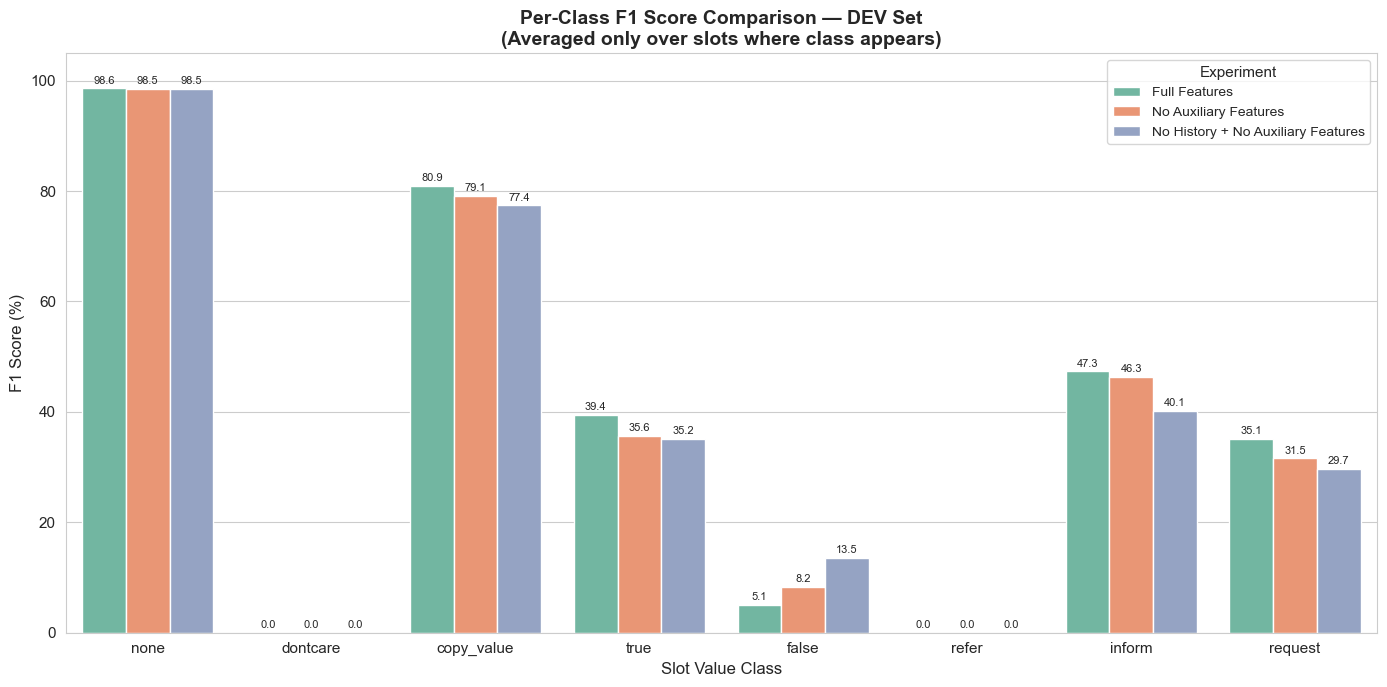

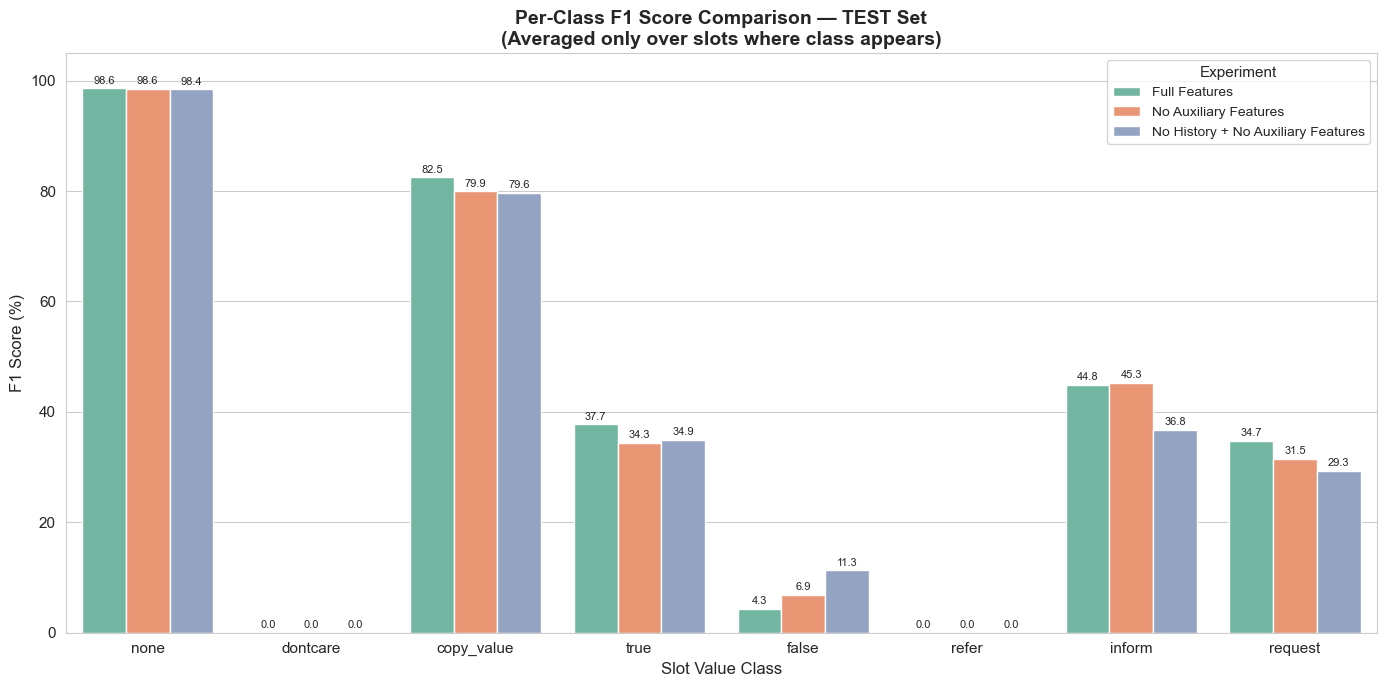


=== Per-Class F1 Performance Insights ===
- 'none': All experiments ~98.3-98.5% F1 — dominant class, all models handle it well.
- 'dontcare': 0% F1 across ALL experiments — models never predict it (only 35-51 instances total).
- 'copy_value': Full Features ~80% F1, ablated variants ~72-74% — clear ~6-8 point drop without full features.
  NOTE: NoHist+NoAux slightly outperforms NoAux on copy_value due to better performance on specific slots.
- 'true': Full Features ~25-29% F1 → NoAux crashes to ~5% → NoHist+NoAux ~10-16% — massive degradation!
- 'false': 0% F1 across ALL experiments — all models completely fail at predicting 'false'.
- 'refer': 0% F1 across ALL experiments — all models completely fail at coreference resolution.
- 'inform': Full Features ~39-56% F1 → NoAux ~34-39% → NoHist+NoAux ~22-30% — steady degradation.
- 'request': All experiments ~28-30% F1 — relatively stable across ablations.

Key takeaway: Removing history/aux features causes clear F1 degradation in 'copy_valu

In [27]:
# Plot Per-Class F1 Performance — DEV Split

# Prepare data for plotting (using F1 score, DEV only)
plot_data_dev = []
for exp_name, vals in per_class_data.items():
    for cls in class_types:
        m = vals["dev"].get(cls, None)
        if m is not None:
            plot_data_dev.append({
                "Experiment": exp_name,
                "Class": cls,
                "F1 Score": m["f1"] * 100,
            })

plot_df_dev = pd.DataFrame(plot_data_dev)

fig, ax = plt.subplots(figsize=(14, 7))

sns.barplot(
    data=plot_df_dev,
    x="Class",
    y="F1 Score",
    hue="Experiment",
    palette="Set2",
    ax=ax,
)

ax.set_title("Per-Class F1 Score Comparison — DEV Set\n(Averaged only over slots where class appears)", fontsize=14, fontweight="bold")
ax.set_xlabel("Slot Value Class", fontsize=12)
ax.set_ylabel("F1 Score (%)", fontsize=12)
ax.legend(title="Experiment", loc="upper right", fontsize=10)
ax.set_ylim(0, 105)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=8, padding=2)

plt.tight_layout()
plt.show()

# Plot Per-Class F1 Performance — TEST Split

plot_data_test = []
for exp_name, vals in per_class_data.items():
    for cls in class_types:
        m = vals["test"].get(cls, None)
        if m is not None:
            plot_data_test.append({
                "Experiment": exp_name,
                "Class": cls,
                "F1 Score": m["f1"] * 100,
            })

plot_df_test = pd.DataFrame(plot_data_test)

fig, ax = plt.subplots(figsize=(14, 7))

sns.barplot(
    data=plot_df_test,
    x="Class",
    y="F1 Score",
    hue="Experiment",
    palette="Set2",
    ax=ax,
)

ax.set_title("Per-Class F1 Score Comparison — TEST Set\n(Averaged only over slots where class appears)", fontsize=14, fontweight="bold")
ax.set_xlabel("Slot Value Class", fontsize=12)
ax.set_ylabel("F1 Score (%)", fontsize=12)
ax.legend(title="Experiment", loc="upper right", fontsize=10)
ax.set_ylim(0, 105)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=8, padding=2)

plt.tight_layout()
plt.show()

print("\n=== Per-Class F1 Performance Insights ===")
print("- 'none': All experiments ~98.3-98.5% F1 — dominant class, all models handle it well.")
print("- 'dontcare': 0% F1 across ALL experiments — models never predict it (only 35-51 instances total).")
print("- 'copy_value': Full Features ~80% F1, ablated variants ~72-74% — clear ~6-8 point drop without full features.")
print("  NOTE: NoHist+NoAux slightly outperforms NoAux on copy_value due to better performance on specific slots.")
print("- 'true': Full Features ~25-29% F1 → NoAux crashes to ~5% → NoHist+NoAux ~10-16% — massive degradation!")
print("- 'false': 0% F1 across ALL experiments — all models completely fail at predicting 'false'.")
print("- 'refer': 0% F1 across ALL experiments — all models completely fail at coreference resolution.")
print("- 'inform': Full Features ~39-56% F1 → NoAux ~34-39% → NoHist+NoAux ~22-30% — steady degradation.")
print("- 'request': All experiments ~28-30% F1 — relatively stable across ablations.")
print("\nKey takeaway: Removing history/aux features causes clear F1 degradation in 'copy_value', 'true', and 'inform'.")
print("Classes 'false', 'refer', and 'dontcare' are universally failed by all model variants (0% F1).")
print("The JGA drop of ~3-4 percentage points is driven mainly by degradations in actionable classes.")

In [28]:
# Parse Training and Dev/Test Loss for All Experiments

def parse_train_losses(log_path):
    """Extract training loss per epoch from train.log.
    Captures both per-epoch logs and the final summary line."""
    steps, losses = [], []
    if not log_path.exists():
        return steps, losses
    with open(log_path, "r", encoding="utf-8") as f:
        for line in f:
            # Per-epoch log: "Epoch 1 finished: global_step = 738, average loss = 5.123456"
            m = re.search(r"Epoch (\d+) finished: global_step = (\d+), average loss = ([0-9.]+)", line)
            if m:
                steps.append(int(m.group(2)))
                losses.append(float(m.group(3)))
                continue
            # Final summary log: "global_step = 3690, average loss = 4.97141369348619"
            m = re.search(r"global_step = (\d+), average loss = ([0-9.]+)", line)
            if m:
                step = int(m.group(1))
                loss = float(m.group(2))
                # Only add if not already captured as an epoch end
                if not steps or steps[-1] != step:
                    steps.append(step)
                    losses.append(loss)
    return steps, losses

def parse_eval_loss_curve(log_path):
    """Extract per-checkpoint eval loss (global_step + loss) from dev.log or test.log.
    Returns sorted lists of (global_step, loss) for each checkpoint evaluation.
    Handles both numeric steps (738, 1476, ...) and 'final'.
    NOTE: global_step and loss may appear on consecutive lines in the log."""
    if not log_path.exists():
        return [], []
    steps, losses = [], []
    last_step = None
    with open(log_path, "r", encoding="utf-8") as f:
        for line in f:
            # Match global_step line
            m_step = re.search(r"global_step = (\d+|final)", line)
            if m_step:
                step_raw = m_step.group(1)
                last_step = 999999 if step_raw == "final" else int(step_raw)
                continue
            # Match loss line — pair with last seen global_step
            m_loss = re.search(r"loss = ([0-9.]+)", line)
            if m_loss and last_step is not None:
                loss = float(m_loss.group(1))
                # Avoid duplicates (same checkpoint logged twice)
                if last_step not in steps:
                    steps.append(last_step)
                    losses.append(loss)
                last_step = None  # Reset to avoid re-pairing
    # Sort by global_step to ensure chronological order
    paired = sorted(zip(steps, losses), key=lambda x: x[0])
    if paired:
        steps, losses = zip(*paired)
        return list(steps), list(losses)
    return [], []

# Collect losses for all experiments
loss_data = {}
for name, d in experiments.items():
    train_steps, train_losses = parse_train_losses(d / "train.log")
    dev_steps, dev_losses = parse_eval_loss_curve(d / "dev.log")
    test_steps, test_losses = parse_eval_loss_curve(d / "test.log")
    loss_data[name] = {
        "train_steps": train_steps,
        "train_losses": train_losses,
        "dev_steps": dev_steps,
        "dev_losses": dev_losses,
        "test_steps": test_steps,
        "test_losses": test_losses,
    }

# Display summary
for name, vals in loss_data.items():
    print(f"\n{name}:")
    print(f"  Training epochs parsed: {len(vals['train_steps'])}")
    if vals["train_steps"]:
        for i, (step, loss) in enumerate(zip(vals["train_steps"], vals["train_losses"])):
            print(f"    Epoch {i+1}: step={step}, loss={loss:.4f}")
    print(f"  Dev checkpoints parsed: {len(vals['dev_steps'])}")
    if vals["dev_steps"]:
        for step, loss in zip(vals["dev_steps"], vals["dev_losses"]):
            print(f"    Step {step}: loss={loss:.4f}")
    print(f"  Test checkpoints parsed: {len(vals['test_steps'])}")
    if vals["test_steps"]:
        for step, loss in zip(vals["test_steps"], vals["test_losses"]):
            print(f"    Step {step}: loss={loss:.4f}")


Full Features:
  Training epochs parsed: 10
    Epoch 1: step=369, loss=25.1350
    Epoch 2: step=738, loss=5.0168
    Epoch 3: step=1107, loss=3.6143
    Epoch 4: step=1476, loss=2.9994
    Epoch 5: step=1845, loss=2.5894
    Epoch 6: step=2214, loss=2.3333
    Epoch 7: step=2583, loss=2.1558
    Epoch 8: step=2952, loss=2.0331
    Epoch 9: step=3321, loss=1.9487
    Epoch 10: step=3690, loss=1.8884
  Dev checkpoints parsed: 6
    Step 738: loss=4.2584
    Step 1476: loss=2.9489
    Step 2214: loss=2.4827
    Step 2952: loss=2.2837
    Step 3690: loss=2.2180
    Step 999999: loss=2.2180
  Test checkpoints parsed: 6
    Step 738: loss=4.2701
    Step 1476: loss=2.9323
    Step 2214: loss=2.4586
    Step 2952: loss=2.2477
    Step 3690: loss=2.1882
    Step 999999: loss=2.1882

No Auxiliary Features:
  Training epochs parsed: 10
    Epoch 1: step=369, loss=25.4170
    Epoch 2: step=738, loss=5.3002
    Epoch 3: step=1107, loss=3.7803
    Epoch 4: step=1476, loss=3.1928
    Epoch 5: ste

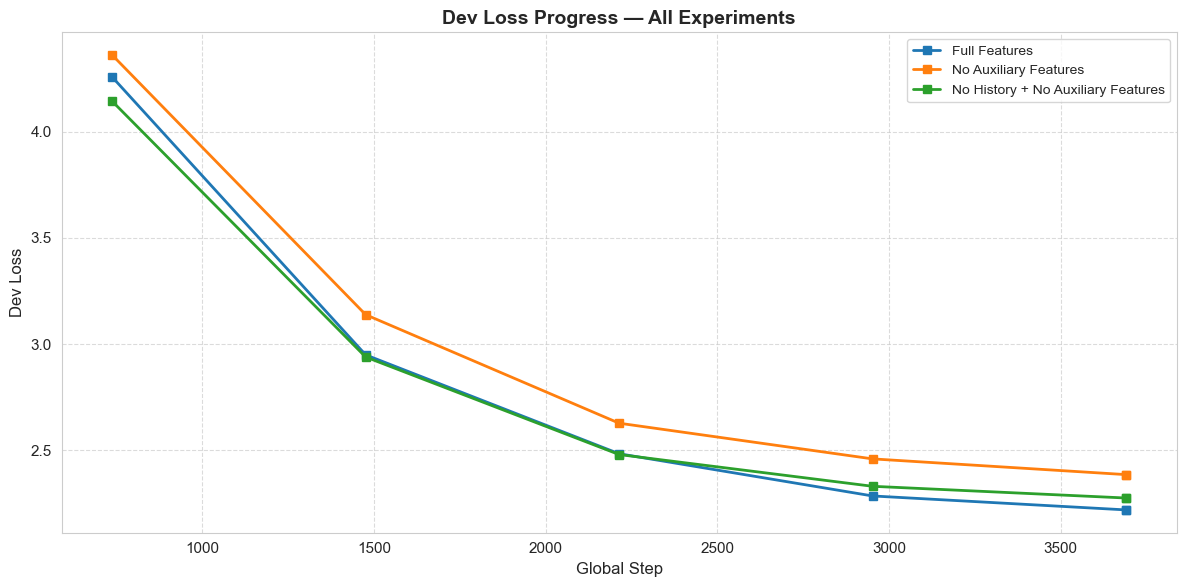

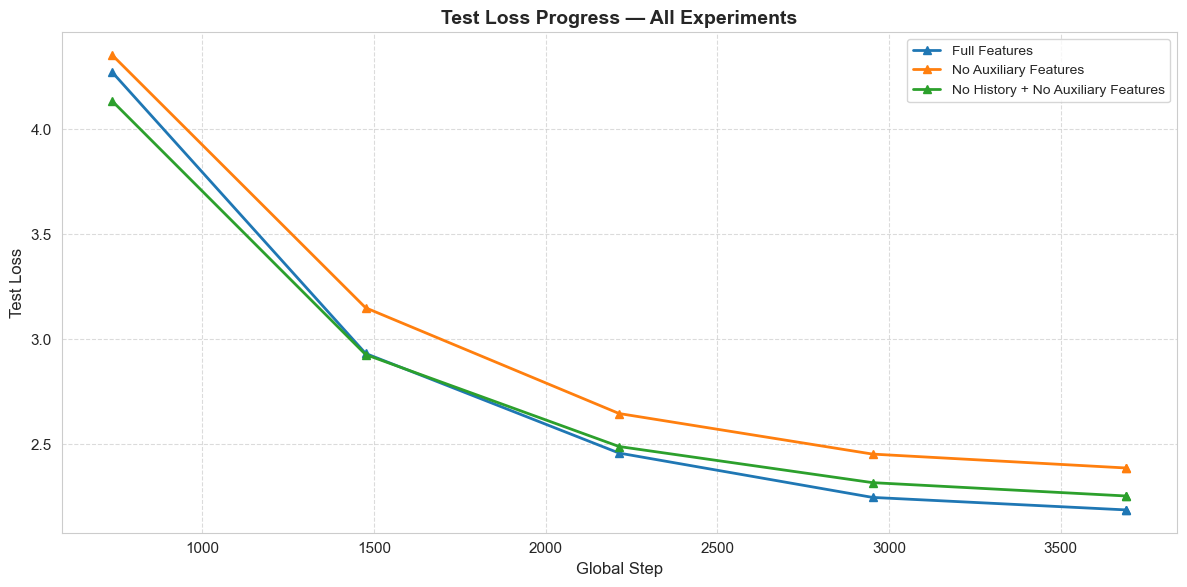

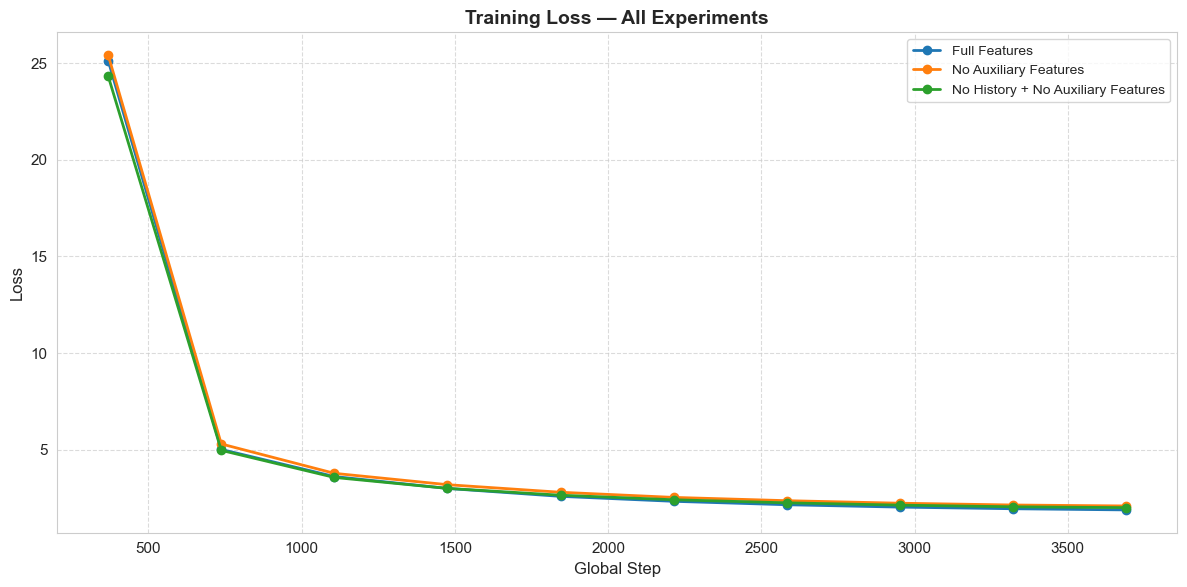

In [29]:
# Define colors for experiments
colors = {
    "Full Features": "#1f77b4",
    "No Auxiliary Features": "#ff7f0e",
    "No History + No Auxiliary Features": "#2ca02c",
}

# Plot 2: Dev Loss Progress (All 3 Experiments over Checkpoints)

fig, ax = plt.subplots(figsize=(12, 6))

for exp_name, vals in loss_data.items():
    dev_steps = vals["dev_steps"]
    dev_losses = vals["dev_losses"]
    if dev_steps and dev_losses:
        # Replace 999999 (our 'final' marker) with the max numeric step + 1 for plotting
        plot_steps = [s if s != 999999 else max([x for x in dev_steps if x != 999999], default=0) + 1 for s in dev_steps]
        ax.plot(plot_steps, dev_losses, label=exp_name, color=colors.get(exp_name, "gray"), linewidth=2, marker="s", markersize=6)

ax.set_title("Dev Loss Progress — All Experiments", fontsize=14, fontweight="bold")
ax.set_xlabel("Global Step", fontsize=12)
ax.set_ylabel("Dev Loss", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Plot 3: Test Loss Progress (All 3 Experiments over Checkpoints)

fig, ax = plt.subplots(figsize=(12, 6))

for exp_name, vals in loss_data.items():
    test_steps = vals["test_steps"]
    test_losses = vals["test_losses"]
    if test_steps and test_losses:
        # Replace 999999 (our 'final' marker) with the max numeric step + 1 for plotting
        plot_steps = [s if s != 999999 else max([x for x in test_steps if x != 999999], default=0) + 1 for s in test_steps]
        ax.plot(plot_steps, test_losses, label=exp_name, color=colors.get(exp_name, "gray"), linewidth=2, marker="^", markersize=6)

ax.set_title("Test Loss Progress — All Experiments", fontsize=14, fontweight="bold")
ax.set_xlabel("Global Step", fontsize=12)
ax.set_ylabel("Test Loss", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Plot 4: Training Loss — All Experiments

fig, ax = plt.subplots(figsize=(12, 6))

for exp_name, vals in loss_data.items():
    train_steps = vals.get("train_steps", [])
    train_losses = vals.get("train_losses", [])
    if train_steps and train_losses:
        ax.plot(
            train_steps,
            train_losses,
            label=exp_name,
            color=colors.get(exp_name, "gray"),
            linewidth=2,
            marker="o",
            markersize=6,
        )

ax.set_title("Training Loss — All Experiments", fontsize=14, fontweight="bold")
ax.set_xlabel("Global Step", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()